In [66]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

In [67]:
from src.paths import DATA_DIR
from src.Qlassifier.baseline import run_tf_idf
from src.Qlassifier.evaluation import correct_in_top3

In [68]:
subjects = ["chemistry", "specialist_mathematics"]
exams = ["2023", "2023_2"]

dfs = []
cos_lst = []
for subject, exam in zip(subjects, exams):
    subject_path = DATA_DIR / subject
    exam_path = subject_path / "past_exams" / f"{exam}.pdf"
    df, cos = run_tf_idf(exam_path)
    dfs.append(df)
    cos_lst.append(cos)

## Evaluation

Since I am no expert in chemistry, I supplied GPT-5 with the necessary documents and asked it to hand-label the best topic classificaitons for us. Unfortunately, for whatever reason, gpt-5 could only reliably label MCQ questions and wasn't very helpful for short answer ones. But alas, even the mcq was of very low quality - by my calculations even worse than this rudimentary TF-IDF approach - as i detected with my limited chemistry knowledge. So, I will hand label on this occasion to the best of my ability, with the help of GPT-5 on individual questions, one at a time.

In [ ]:
true_topic_mcq = [
    0, 2, 6, 5, 10, 9, 0, 4, 0, 4,
    3, 3, 6, 4, 0, 9, 1, 9, 6, 8,
    10 ,2, 6, 2, 5, 11, 12, 2, 9, 2,
]

true_topic_indices = true_topic_mcq + [
    6, 7, 7, 6, 6, 2, 2, 2, 2,   # Q1
    6, 10, 10, 10, 6, 10, 6, 10, # Q2
    0, 0, 0, 0, 0, 6,            # Q3
    7, 6, 7, 7, 7,               # Q4
    0, 4, 4, 3,                  # Q5
    2, 2, 2, 2, 2,               # Q6 
    9, 9, 9, 9, 9,               # Q7
    3, 12, 12, 1, 1, 11, 11, 11, # Q8
    5, 5                         # Q9
]

chem_df = dfs[0]
cos_chem = cos_lst[0] # cosine similarities
chem_df["true_topic_idx"] = true_topic_indices
mcq_chem = chem_df.loc[:29]

In [85]:
incorrect_chem = chem_df[chem_df["pred_topic_idx"] != chem_df["true_topic_idx"]]
correct_chem = chem_df[chem_df["pred_topic_idx"] == chem_df["true_topic_idx"]]
incorrect_chem.head(5)

,label,text,comments,pred_topic_idx,pred_topic,Confidence,true_topic_idx
6,Question 7.,Consider the following statements about fossil...,Biofuel production potentially does damage the...,1,Measuring changes in chemical reactions,0.421371,0
10,Question 11.,student conducted an experiment to determine t...,Reaction rate is the change in the quantity of...,4,Extent of chemical reactions,0.488327,3
14,Question 15.,Consider two types of drone: petrol-powered an...,Petrol-powered drones convert chemical energy ...,1,Measuring changes in chemical reactions,0.494793,0
17,Question 18.,The graph below shows the HPLC calibration cur...,According to the calibration curve for diluted...,4,Extent of chemical reactions,0.411729,9
19,Question 20.,Which one of the following is always correct w...,There was no correct or best answer to this qu...,5,Production of chemicals using electrolysis,0.396338,8


Let's check how good our confidence metric is.

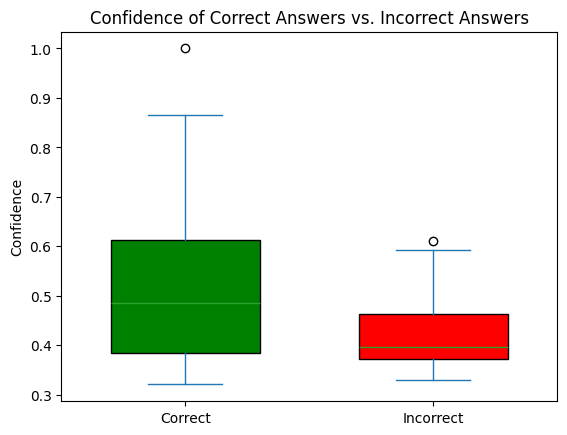

In [99]:
from matplotlib import pyplot as plt

def plot_conf(df):
    incorrect_df = df[df["pred_topic_idx"] != df["true_topic_idx"]]
    correct_df = df[df["pred_topic_idx"] == df["true_topic_idx"]]

    _, ax = plt.subplots()

    correct_df["Confidence"].plot(kind="box", ax=ax, positions=[1], patch_artist=True,
                                  widths=0.6, boxprops=dict(facecolor="green"))
    incorrect_df["Confidence"].plot(kind="box", ax=ax, positions=[2], widths = 0.6, 
                                    patch_artist=True, boxprops=dict(facecolor="red"))

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Correct", "Incorrect"])

    ax.set_title("Confidence of Correct Answers vs. Incorrect Answers")
    ax.set_ylabel("Confidence")

    plt.show()

plot_conf(chem_df)

A rough threshold for a "confident estimate" might be around 0.6.

Our goal isn't really to JUST assign a question to a topic; this is a flawed problem design, since questions may belong to multiple topics. The hand labelling above was just what I deemed to be the single BEST answer. In reality, its the distribution of the weights for each topic that we are interested in. We also didn't test short answer (since the labelling is tedious to say the least, and the one "true label" is even more ambiguous). 

So we incorporate an accuracy metric plus something to determine how sensical are answers are. 

In [112]:
def evaluate_tf_idf(df, mcq_df, cos):
    correct_mcq = mcq_df[mcq_df["pred_topic_idx"] == mcq_df["true_topic_idx"]]
    correct_df = df[df["pred_topic_idx"] == df["true_topic_idx"]]

    accuracy_mcq = len(correct_mcq) / len(mcq_df)
    accuracy = len(correct_df) / len(df)
    print(f"Accuracy on MCQ: {100*accuracy_mcq:.1f}%")
    print(f"Accuracy overall: {100*accuracy:.1f}%")


    print("The percentage of time the correct topic is among the top 3 predicted topics (MCQ only) is "
      f"{100*(sum([correct_in_top3(qn_idx, mcq_df, cos) for qn_idx in range(len(mcq_df))]) / len(mcq_df)):.2f}%")
    
    print("The percentage of time the correct topic is among the top 3 predicted topics is "
      f"{100*(sum([correct_in_top3(qn_idx, df, cos) for qn_idx in range(len(df))]) / len(df)):.2f}%")

evaluate_tf_idf(chem_df, mcq_chem, cos_chem)

Accuracy on MCQ: 73.3%
Accuracy overall: 57.3%
The percentage of time the correct topic is among the top 3 predicted topics (MCQ only) is 90.00%
The percentage of time the correct topic is among the top 3 predicted topics is 70.73%


We move on to a mathematics subject, in which we expect our 'model' to perform FAR worse, since we don't have LaTeX data and plenty of the context is in the LaTeX for math exams, especially relative to chemistry ones. This one I hand label reliably.

In [110]:
mcq_labels = [
    0, 1, 1, 2, 2, 4, 4, 4, 7, 3, 
    3, 5, 5, 6, 6, 8, 6, 7, 9, 11,
]

ground_truth = mcq_labels + [
    1, 3, 3, 3, 7, 8, 3, 3,            # Q1
    2, 2, 2, 2, 2, 2, 2, 2,            # Q2
    3, 3, 3, 3, 3, 3,                  # Q3
    4, 4, 4, 4, 4, 4, 1, 4,            # Q4
    6, 6, 7, 7, 7, 7,                  # Q5
    11, 11, 11, 12, 12, 12, 12, 12, 10 # Q6  

]

math_df = dfs[1]
cos_math = cos_lst[1]
math_df["true_topic_idx"] = ground_truth
mcq_math = math_df.loc[:19]
math_df.head(5)

,label,text,comments,pred_topic_idx,pred_topic,Confidence,true_topic_idx
0,Question 1.,Consider the following statement. ‘If my footb...,,0,Logic and proof,0.540743,0
1,Question 2.,The graph of ax bx has asymptotes given by and...,,10,Distribution of the sample mean,0.348711,1
2,Question 3.,"In the interval π π the graph of sec( ), where...",,11,Confidence intervals for the population mean,0.581226,1
3,Question 4.,"If − 1) ai where is non-zero real constant, t...",,9,Distribution of linear combinations of random ...,1.000000,2
4,Question 5.,Let be complex number where Re( and Im( 0. Giv...,,2,Complex numbers,0.499708,2


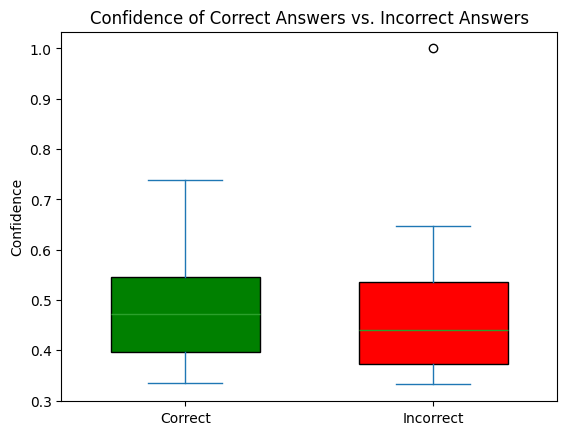

In [106]:
plot_conf(math_df)

We can see that confidence means less in this case. But it does still have some meaning, since we see decent evidence of separation b/w the two classes in the extrema. Regardless the metric is clearly flawed since the maximum confidence belonged to an incorrect answer. We take it with a grain of salt (perhaps weigh by confidence very lightly when incorporating with other models).

In [113]:
evaluate_tf_idf(math_df, mcq_math, cos_math)

Accuracy on MCQ: 45.0%
Accuracy overall: 43.1%
The percentage of time the correct topic is among the top 3 predicted topics (MCQ only) is 60.00%
The percentage of time the correct topic is among the top 3 predicted topics is 63.08%


As expected! These results will serve as our baseline. 

In [114]:
math_df.to_csv("results/tf_idf_math_out.csv")
chem_df.to_csv("results/tf_idf_chem_out.csv")